# Policy Gradient Training: using Mihir's CNN (M1)

**M1 = Mihir's CNN** — single input `(6, 7, 2)`, softmax output over 7 columns, ~2M parameters.  
**Opponents (M2 pool):** Cass's CNN, Sophia's CNN, Paolo's CNN, and updated copies of M1 itself.

### Improvements over baseline notebooks
| What | Baseline | This notebook |
|---|---|---|
| Iterations | 600 | **3,000** |
| Temperature | Fixed 1.1 | **Annealed 1.3 → 0.8** |
| Reward normalisation | None | **Zero-mean / unit-std per batch** |
| Draw reward | Fixed +0.05 | **Annealed +0.1 → 0.0** |
| Learning rate | Fixed 1e-4 | **Warm-up then cosine decay** |
| Opponent weighting | Uniform random | **Harder opponents weighted more as training progresses** |

## 1. Imports

In [1]:
import numpy as np
import tensorflow as tf
import keras
import json, h5py, random, os, math
import matplotlib.pyplot as plt
from collections import deque

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('Keras:     ', keras.__version__)

/opt/anaconda3/envs/capstone/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


TensorFlow: 2.19.0
Keras:      3.13.2


## 2. Load Models

- **Mihir** — single input `(6,7,2)`, softmax output. This is **M1**, the model we train.
- **Cass** — single input `(6,7,2)`, softmax output.
- **Sophia** — dual input `[(6,7,2), (7,)]` (board + legal-move mask), masked logit output.
- **Paolo** — single input `(6,7,2)`, softmax output. Loaded via `config.json` + `model.weights.h5`
  because its layer names differ between the config and the weight file.

In [2]:
# ── Load M1: Mihir's CNN ─────────────────────────────────────────────────────
m1 = keras.models.load_model('mihir_cnn_connect4.h5', compile=False)
print('M1 (Mihir) loaded')
print('  Input shape: ', m1.input_shape)
print('  Output shape:', m1.output_shape)
print('  Parameters:  ', m1.count_params())

# ── Load M2 opponents ────────────────────────────────────────────────────────
m2_cass = keras.models.load_model('cass_cnn_connect4.keras', compile=False)
print('\nM2 Cass loaded   — input:', m2_cass.input_shape)

m2_sophia = keras.models.load_model('Sophia_CNN.keras', compile=False)
print('M2 Sophia loaded — input:', m2_sophia.input_shape, '(dual)')

# Paolo requires positional weight loading (layer name mismatch between
# config.json and model.weights.h5 — verified by inspecting both files).
def load_paolo():
    def loss_fn(y_true, y_pred):
        return keras.losses.categorical_crossentropy(y_true, y_pred)
    with open('config.json') as f:
        cfg = json.load(f)
    model = keras.models.model_from_json(
        json.dumps(cfg), custom_objects={'loss_fn': loss_fn}
    )
    # Map h5 keys (conv2d, conv2d_1 …) → model layers positionally
    h5_keys = [
        'input_layer', 'conv2d', 'batch_normalization', 'activation', 'dropout',
        'conv2d_1', 'batch_normalization_1', 'activation_1', 'dropout_1',
        'conv2d_2', 'batch_normalization_2', 'activation_2', 'dropout_2',
        'conv2d_3', 'batch_normalization_3', 'activation_3', 'dropout_3',
        'flatten', 'dense', 'dropout_4', 'dense_1',
    ]
    with h5py.File('model.weights.h5', 'r') as f:
        for layer, key in zip(model.layers, h5_keys):
            if key in f['layers'] and 'vars' in f['layers'][key]:
                grp = f['layers'][key]['vars']
                wts = [grp[str(i)][()] for i in sorted(grp.keys(), key=int)]
                if wts:
                    layer.set_weights(wts)
    return model

m2_paolo = load_paolo()
print('M2 Paolo loaded  — input:', m2_paolo.input_shape)

print('\nAll models loaded successfully.')

M1 (Mihir) loaded
  Input shape:  (None, 6, 7, 2)
  Output shape: (None, 7)
  Parameters:   2002823

M2 Cass loaded   — input: (None, 6, 7, 2)
M2 Sophia loaded — input: [(None, 6, 7, 2), (None, 7)] (dual)
M2 Paolo loaded  — input: (None, 6, 7, 2)

All models loaded successfully.


## 3. Connect-4 Game Engine

Board: 6×7 integer array. `0` = empty, `1` = player 1, `2` = player 2.  
Pieces fall to the lowest empty row (row 5 = bottom).  
Board encoding for networks: `(6, 7, 2)` float32 — channel 0 = current player, channel 1 = opponent.

In [3]:
ROWS, COLS = 6, 7

def create_board():
    return np.zeros((ROWS, COLS), dtype=int)

def drop_piece(board, col, player):
    """Return new board with player's piece in column col (gravity)."""
    board = board.copy()
    for row in range(ROWS - 1, -1, -1):
        if board[row][col] == 0:
            board[row][col] = player
            return board
    return board

def get_legal_moves(board):
    return [c for c in range(COLS) if board[0][c] == 0]

def get_mask(board):
    """Float mask: 1.0 if column is legal, 0.0 if full. Used by Sophia's model."""
    return np.array([1.0 if board[0][c] == 0 else 0.0
                     for c in range(COLS)], dtype=np.float32)

def check_win(board, player):
    """Return True if player has four in a row (any direction)."""
    b, p = board, player
    for r in range(ROWS):                        # horizontal
        for c in range(COLS - 3):
            if b[r,c]==p and b[r,c+1]==p and b[r,c+2]==p and b[r,c+3]==p:
                return True
    for r in range(ROWS - 3):                    # vertical
        for c in range(COLS):
            if b[r,c]==p and b[r+1,c]==p and b[r+2,c]==p and b[r+3,c]==p:
                return True
    for r in range(ROWS - 3):                    # diagonal \
        for c in range(COLS - 3):
            if b[r,c]==p and b[r+1,c+1]==p and b[r+2,c+2]==p and b[r+3,c+3]==p:
                return True
    for r in range(3, ROWS):                     # diagonal /
        for c in range(COLS - 3):
            if b[r,c]==p and b[r-1,c+1]==p and b[r-2,c+2]==p and b[r-3,c+3]==p:
                return True
    return False

def encode_board(board, player):
    """Encode board as (6, 7, 2) float32 from player's perspective."""
    enc = np.zeros((ROWS, COLS, 2), dtype=np.float32)
    enc[:,:,0] = (board == player).astype(np.float32)
    enc[:,:,1] = (board == (3 - player)).astype(np.float32)
    return enc

def get_winning_move(board, player):
    """Return a column that wins immediately for player, or None."""
    for c in get_legal_moves(board):
        if check_win(drop_piece(board, c, player), player):
            return c
    return None

def get_non_losing_moves(board, player):
    """Columns that don't hand the opponent an immediate win next turn.
    Falls back to all legal moves if every move loses."""
    opp  = 3 - player
    safe = []
    for c in get_legal_moves(board):
        b2 = drop_piece(board, c, player)
        if get_winning_move(b2, opp) is None:
            safe.append(c)
    return safe if safe else get_legal_moves(board)

# Quick sanity check
b = create_board()
b = drop_piece(b, 3, 1)
b = drop_piece(b, 2, 2)
print('Board:', b, sep='\n')
print('Legal moves:', get_legal_moves(b))
print('Encoded shape:', encode_board(b, 1).shape)

Board:
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 2 1 0 0 0]]
Legal moves: [0, 1, 2, 3, 4, 5, 6]
Encoded shape: (6, 7, 2)


## 4. Move Selection

**M1 (Mihir)** — single input, softmax output. Samples over **legal moves only**.  
**M2 (Cass / Paolo)** — same interface.  
**M2 (Sophia)** — dual input `[board, mask]`, masked logit output, softmax applied manually.  

M2 plays **smartly**: win immediately → block M1's win → sample from non-losing moves.  
M1 gets **no heuristic help** — it must learn strong play through gradient descent alone (adversarial training principle).

In [4]:
def get_probs_single(model, board, player):
    """Forward pass for single-input models (Mihir, Cass, Paolo).
    Zeros illegal columns and renormalises."""
    enc   = encode_board(board, player)[np.newaxis]   # (1,6,7,2)
    probs = model(enc, training=False).numpy()[0]      # (7,) softmax
    mask  = get_mask(board)
    probs = probs * mask
    total = probs.sum()
    return probs / total if total > 1e-8 else mask / mask.sum()

def get_probs_sophia(model, board, player):
    """Forward pass for Sophia's dual-input model.
    Model outputs masked logits; we apply softmax manually."""
    enc    = encode_board(board, player)[np.newaxis]   # (1,6,7,2)
    mask   = get_mask(board)[np.newaxis]               # (1,7)
    logits = model([enc, mask], training=False).numpy()[0]  # (7,)
    logits -= logits.max()                             # numerical stability
    exp_l  = np.exp(logits)
    return exp_l / exp_l.sum()

def get_probs(model, model_type, board, player):
    """Dispatch based on model_type: 'single' or 'sophia'."""
    if model_type == 'sophia':
        return get_probs_sophia(model, board, player)
    return get_probs_single(model, board, player)

def sample_move(probs, legal_moves, temperature=1.0):
    """Sample a column. temperature > 1 = more uniform; < 1 = sharper/greedier."""
    lp = np.array([probs[c] for c in legal_moves], dtype=np.float64)
    lp = lp ** (1.0 / temperature)   # apply temperature in prob space
    lp /= lp.sum()
    return int(np.random.choice(legal_moves, p=lp))

def choose_m2(model, model_type, board, player, temperature=0.8):
    """Smart M2 strategy:
      1. Win immediately if possible.
      2. Block M1's immediate win.
      3. Sample from non-losing moves via model (low temperature = sharper).
    Per spec: M2 is made strong so M1 must learn through SGD, not exploit weak opponents.
    """
    col = get_winning_move(board, player)
    if col is not None:
        return col
    col = get_winning_move(board, 3 - player)   # block
    if col is not None:
        return col
    safe  = get_non_losing_moves(board, player)
    probs = get_probs(model, model_type, board, player)
    return sample_move(probs, safe, temperature=temperature)

def choose_m1(model, board, player, temperature=1.3):
    """M1 samples over legal moves only — no heuristic help.
    Per spec: 'only allow M1 to look for legal moves'."""
    probs = get_probs_single(model, board, player)
    return sample_move(probs, get_legal_moves(board), temperature=temperature)

## 5. Game Play

Each game:
1. **Random warm-start**: `N_RANDOM_INIT` moves played uniformly at random — diversifies board states encountered. These are **not recorded** (per spec).
2. **Strategic phase**: M1 vs M2 until terminal state.
3. Returns M1's `(encoded_board, col)` experience tuples and the final outcome.

In [5]:
def play_game(m1_model, m2_model, m2_type, m1_player,
              n_random_init=4, m1_temp=1.3, m2_temp=0.8):
    """
    Play one game of M1 vs M2.

    Returns
    -------
    experiences : list of (encoded_board, col) — one per M1 move
    outcome     : 'win', 'loss', or 'draw' from M1's perspective
    """
    board          = create_board()
    current_player = 1
    m1_experiences = []

    # ── Random warm-start (NOT recorded) ─────────────────────────────────────
    for _ in range(n_random_init):
        legal = get_legal_moves(board)
        if not legal:
            break
        board = drop_piece(board, random.choice(legal), current_player)
        # If the random moves accidentally end the game, start fresh
        if check_win(board, current_player) or not get_legal_moves(board):
            board          = create_board()
            current_player = 1
            continue
        current_player = 3 - current_player

    # ── Strategic phase ───────────────────────────────────────────────────────
    while True:
        legal = get_legal_moves(board)
        if not legal:
            return m1_experiences, 'draw'

        if current_player == m1_player:
            # M1's turn — legal moves only, no heuristic help
            enc = encode_board(board, m1_player)
            col = choose_m1(m1_model, board, m1_player, temperature=m1_temp)
            m1_experiences.append((enc.copy(), col))
        else:
            # M2's turn — smart strategy
            col = choose_m2(m2_model, m2_type, board, 3 - m1_player,
                            temperature=m2_temp)

        board = drop_piece(board, col, current_player)

        if check_win(board, current_player):
            outcome = 'win' if current_player == m1_player else 'loss'
            return m1_experiences, outcome

        current_player = 3 - current_player

## 6. Discounted Rewards

$$R_t = \gamma^{(T-1-t)} \cdot r_{\text{final}}$$

- **Win** → $r_{\text{final}} = +1$  
- **Loss** → $r_{\text{final}} = -1$  
- **Draw** → $r_{\text{final}}$ anneals from $+0.1$ down to $0.0$ — stops rewarding draws once M1 is strong enough to aim for wins.

Rewards are then **normalised to zero mean / unit std** within each batch. This stabilises the gradient magnitude regardless of how sparse wins are early in training.

In [6]:
def compute_discounted_rewards(n_moves, outcome, gamma=0.95, draw_reward=0.05):
    """
    Compute per-move discounted returns for M1.

    Parameters
    ----------
    n_moves     : number of moves M1 made
    outcome     : 'win', 'loss', or 'draw'
    gamma       : discount factor
    draw_reward : reward assigned for a draw (annealed during training)
    """
    if outcome == 'win':
        final_r = 1.0
    elif outcome == 'loss':
        final_r = -1.0
    else:
        final_r = draw_reward

    return [(gamma ** (n_moves - 1 - t)) * final_r for t in range(n_moves)]

def normalise_rewards(rewards):
    """Zero-mean / unit-std normalisation. Stabilises gradient magnitude.
    Returns the original array unchanged if std is too small (all same reward)."""
    r = np.array(rewards, dtype=np.float32)
    if r.std() > 1e-8:
        r = (r - r.mean()) / (r.std() + 1e-8)
    return r

# Sanity check
print('5-move win (raw):  ', np.round(compute_discounted_rewards(5, 'win'), 4))
print('5-move loss (raw): ', np.round(compute_discounted_rewards(5, 'loss'), 4))
print('Normalised win:    ', np.round(normalise_rewards(compute_discounted_rewards(5, 'win')), 4))

5-move win (raw):   [0.8145 0.8574 0.9025 0.95   1.    ]
5-move loss (raw):  [-0.8145 -0.8574 -0.9025 -0.95   -1.    ]
Normalised win:     [-1.3777 -0.7242 -0.0362  0.6879  1.4502]


## 7. Policy Gradient Training Step

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \log \pi(a_i \mid s_i) \cdot R_i$$

Minimising this loss maximises the expected discounted return — moves that led to wins become more probable, moves that led to losses become less probable.

Mihir's model outputs **softmax probabilities** directly, so we zero-mask illegal columns, renormalise, then take `log`.

Batch size is **fixed at 32** throughout training — required to avoid TensorFlow retracing the compute graph on every step.

In [7]:
BATCH_SIZE = 32   # NEVER change this mid-training — TF graph is traced for this size

# Cosine-decay learning rate schedule:
#   - Warm-up for 100 steps from lr_min → lr_max
#   - Cosine decay from lr_max → lr_min over the remaining steps
LR_MAX    = 3e-4
LR_MIN    = 5e-6
WARMUP    = 100     # gradient steps
N_STEPS   = 3000   # total gradient steps (= N_ITERATIONS)

def get_lr(step):
    """Return learning rate for the given gradient step."""
    if step < WARMUP:
        return LR_MIN + (LR_MAX - LR_MIN) * (step / WARMUP)
    progress = (step - WARMUP) / max(1, N_STEPS - WARMUP)
    return LR_MIN + 0.5 * (LR_MAX - LR_MIN) * (1 + math.cos(math.pi * progress))

optimizer = keras.optimizers.Adam(learning_rate=LR_MAX)

@tf.function  # Compiled graph — must keep input shapes constant!
def pg_train_step(boards, masks, moves, rewards):
    """
    One REINFORCE gradient step.

    boards  : (32, 6, 7, 2)  float32 — board states from M1's perspective
    masks   : (32, 7)        float32 — legal-move masks (1=legal, 0=illegal)
    moves   : (32,)          int32   — column M1 chose
    rewards : (32,)          float32 — normalised discounted returns
    """
    with tf.GradientTape() as tape:
        # Forward pass — Mihir's model outputs softmax probs: (32, 7)
        probs = m1(boards, training=True)

        # Zero illegal columns and renormalise in probability space
        masked = probs * masks
        masked = masked / (tf.reduce_sum(masked, axis=1, keepdims=True) + 1e-8)

        # Log-probabilities; clip to avoid log(0)
        log_probs = tf.math.log(tf.clip_by_value(masked, 1e-7, 1.0))  # (32, 7)

        # Extract log-prob of the action that was actually taken
        indices        = tf.stack([tf.range(BATCH_SIZE), moves], axis=1)  # (32, 2)
        chosen_logprob = tf.gather_nd(log_probs, indices)                  # (32,)

        # PG loss (negative because Adam minimises)
        loss = -tf.reduce_mean(chosen_logprob * rewards)

    grads = tape.gradient(loss, m1.trainable_variables)
    optimizer.apply_gradients(zip(grads, m1.trainable_variables))
    return loss

print('Optimizer and training step ready.')
print(f'LR schedule: warm-up {WARMUP} steps, then cosine decay {LR_MAX:.0e} → {LR_MIN:.0e}')

Optimizer and training step ready.
LR schedule: warm-up 100 steps, then cosine decay 3e-04 → 5e-06


## 8. Main Training Loop

Each iteration:
1. Sample an opponent — harder opponents are weighted more as training progresses.
2. Play `GAMES_PER_ITER` games, collecting M1's `(board, mask, col, reward)` tuples.
3. Sample exactly `BATCH_SIZE=32` tuples and take **one** gradient step.
4. Update learning rate, temperature, and draw-reward according to their schedules.
5. Every `SNAPSHOT_EVERY` iterations, clone the current M1 into the opponent pool (self-play).

In [8]:
# ── Hyper-parameters ──────────────────────────────────────────────────────────
N_ITERATIONS   = 3000   # total gradient steps 
GAMES_PER_ITER = 6      # games per gradient step
GAMMA          = 0.95   # discount factor
N_RANDOM_INIT  = 4      # random warm-start moves per game
SNAPSHOT_EVERY = 300    # add M1 snapshot to pool every N iterations
MAX_SNAPSHOTS  = 5      # max extra M1 copies in pool (originals never removed)

# Temperature schedule: start exploratory (1.3), anneal to exploitative (0.8)
TEMP_START  = 1.3
TEMP_END    = 0.8

# Draw reward schedule: start generous (0.1 — draw is good early on),
# anneal to 0.0 (once M1 is strong, draws are no longer a goal)
DRAW_R_START = 0.1
DRAW_R_END   = 0.0

def anneal(start, end, iteration, total):
    """Linear annealing from start to end over training."""
    return start + (end - start) * (iteration / total)

# ── Opponent pool ─────────────────────────────────────────────────────────────
# Each entry: (model, model_type, weight)
#   weight controls how often this opponent is selected.
#   Original P1 models start at weight 1.0 and are NEVER removed.
#   Harder opponents get upweighted as training progresses.
POOL_ENTRIES = [
    #  model       type       base_weight
    (m2_cass,   'single',   1.0),
    (m2_sophia, 'sophia',   1.0),
    (m2_paolo,  'single',   1.0),
]

# Clone original M1 as a baseline opponent (so M1 trains against itself from day 1)
m1_original = keras.models.clone_model(m1)
m1_original.set_weights(m1.get_weights())
POOL_ENTRIES.append((m1_original, 'single', 1.0))

print(f'Initial pool size: {len(POOL_ENTRIES)} opponents')
print(f'Training for {N_ITERATIONS} iterations ({N_ITERATIONS * GAMES_PER_ITER:,} total games)')

Initial pool size: 4 opponents
Training for 3000 iterations (18,000 total games)


In [9]:
# ── Training ──────────────────────────────────────────────────────────────────
n_snapshots    = 0
grad_step      = 0          # counts actual gradient steps taken
all_outcomes   = []         # 'win'/'loss'/'draw' for every game
loss_history   = []
win_rate_log   = []
lr_log         = []
temp_log       = []
recent         = deque(maxlen=200)   # last 200 game outcomes for rolling stats

for iteration in range(N_ITERATIONS):

    # ── Annealed schedules ────────────────────────────────────────────────────
    m1_temp    = anneal(TEMP_START, TEMP_END,    iteration, N_ITERATIONS)
    draw_r     = anneal(DRAW_R_START, DRAW_R_END, iteration, N_ITERATIONS)

    # ── Opponent selection — weight harder opponents more as training advances ─
    # Ramp snapshot weights from 0.5 → 2.0 over training so M1 increasingly
    # trains against stronger versions of itself (self-play curriculum).
    progress = iteration / N_ITERATIONS
    weights  = []
    for _, mtype, base_w in POOL_ENTRIES:
        # Snapshots (added later) are tagged with base_w=1.5; ramp them up
        w = base_w * (1.0 + progress) if base_w > 1.0 else base_w
        weights.append(w)
    total_w    = sum(weights)
    probs_pool = [w / total_w for w in weights]
    chosen_idx = np.random.choice(len(POOL_ENTRIES), p=probs_pool)
    m2_model, m2_type, _ = POOL_ENTRIES[chosen_idx]

    # ── Play GAMES_PER_ITER games ──────────────────────────────────────────────
    iter_boards  = []
    iter_masks   = []
    iter_moves   = []
    iter_rewards = []

    for _ in range(GAMES_PER_ITER):
        m1_player = random.choice([1, 2])   # randomly decide first-mover

        experiences, outcome = play_game(
            m1, m2_model, m2_type, m1_player,
            n_random_init=N_RANDOM_INIT,
            m1_temp=m1_temp, m2_temp=0.8
        )
        all_outcomes.append(outcome)
        recent.append(outcome)

        if experiences:
            raw_r = compute_discounted_rewards(
                len(experiences), outcome, gamma=GAMMA, draw_reward=draw_r
            )
            for (enc, col), r in zip(experiences, raw_r):
                iter_boards.append(enc)
                # Derive legal-move mask from the encoded board:
                # any column where both channels are 0 in row 0 is still empty
                iter_masks.append((enc[0, :, 0] + enc[0, :, 1] < 0.5).astype(np.float32))
                iter_moves.append(col)
                iter_rewards.append(r)

    # ── Gradient step ──────────────────────────────────────────────────────────
    if len(iter_boards) >= BATCH_SIZE:
        idx = np.random.choice(len(iter_boards), BATCH_SIZE, replace=False)

        b_boards   = np.array([iter_boards[i]  for i in idx], dtype=np.float32)
        b_masks    = np.array([iter_masks[i]   for i in idx], dtype=np.float32)
        b_moves    = np.array([iter_moves[i]   for i in idx], dtype=np.int32)
        b_rewards  = normalise_rewards([iter_rewards[i] for i in idx])

        # Update learning rate
        new_lr = get_lr(grad_step)
        optimizer.learning_rate.assign(new_lr)

        loss_val = pg_train_step(
            tf.constant(b_boards),
            tf.constant(b_masks),
            tf.constant(b_moves),
            tf.constant(b_rewards),
        )
        loss_history.append(float(loss_val))
        lr_log.append(new_lr)
        grad_step += 1

    # ── Logging ───────────────────────────────────────────────────────────────
    wr = sum(1 for o in recent if o == 'win') / len(recent) if recent else 0
    win_rate_log.append(wr)
    temp_log.append(m1_temp)

    if (iteration + 1) % 100 == 0:
        dr   = sum(1 for o in recent if o == 'draw') / len(recent)
        lr   = optimizer.learning_rate.numpy()
        avg_loss = np.mean(loss_history[-50:]) if loss_history else float('nan')
        print(f'Iter {iteration+1:4d}/{N_ITERATIONS} | '
              f'WR={wr:.1%} DR={dr:.1%} | '
              f'temp={m1_temp:.2f} draw_r={draw_r:.3f} | '
              f'lr={lr:.2e} loss={avg_loss:.4f} | '
              f'pool={len(POOL_ENTRIES)}')

    # ── Snapshot M1 into opponent pool (self-play) ────────────────────────────
    # Per spec: original models are never removed; snapshots are added periodically.
    if (iteration + 1) % SNAPSHOT_EVERY == 0 and n_snapshots < MAX_SNAPSHOTS:
        snap = keras.models.clone_model(m1)
        snap.set_weights(m1.get_weights())
        # base_w > 1.0 flags this as a snapshot so the weighting ramp applies
        POOL_ENTRIES.append((snap, 'single', 1.5))
        n_snapshots += 1
        print(f'  → Snapshot {n_snapshots} added. Pool size: {len(POOL_ENTRIES)}')

print('\nTraining complete!')

Iter  100/3000 | WR=40.5% DR=5.5% | temp=1.28 draw_r=0.097 | lr=2.97e-04 loss=-0.1211 | pool=4
Iter  200/3000 | WR=37.0% DR=4.0% | temp=1.27 draw_r=0.093 | lr=2.99e-04 loss=-0.1365 | pool=4
Iter  300/3000 | WR=37.0% DR=8.5% | temp=1.25 draw_r=0.090 | lr=2.97e-04 loss=-0.1392 | pool=4
  → Snapshot 1 added. Pool size: 5
Iter  400/3000 | WR=45.5% DR=6.5% | temp=1.23 draw_r=0.087 | lr=2.92e-04 loss=-0.1412 | pool=5
Iter  500/3000 | WR=44.0% DR=8.0% | temp=1.22 draw_r=0.083 | lr=2.86e-04 loss=-0.1281 | pool=5
Iter  600/3000 | WR=45.5% DR=7.0% | temp=1.20 draw_r=0.080 | lr=2.79e-04 loss=-0.1276 | pool=5
  → Snapshot 2 added. Pool size: 6
Iter  700/3000 | WR=50.5% DR=6.5% | temp=1.18 draw_r=0.077 | lr=2.70e-04 loss=-0.1718 | pool=6
Iter  800/3000 | WR=42.5% DR=5.0% | temp=1.17 draw_r=0.073 | lr=2.60e-04 loss=-0.1456 | pool=6
Iter  900/3000 | WR=49.0% DR=3.5% | temp=1.15 draw_r=0.070 | lr=2.48e-04 loss=-0.1115 | pool=6
  → Snapshot 3 added. Pool size: 7
Iter 1000/3000 | WR=51.0% DR=7.0% | temp

## 9. Results & Plots

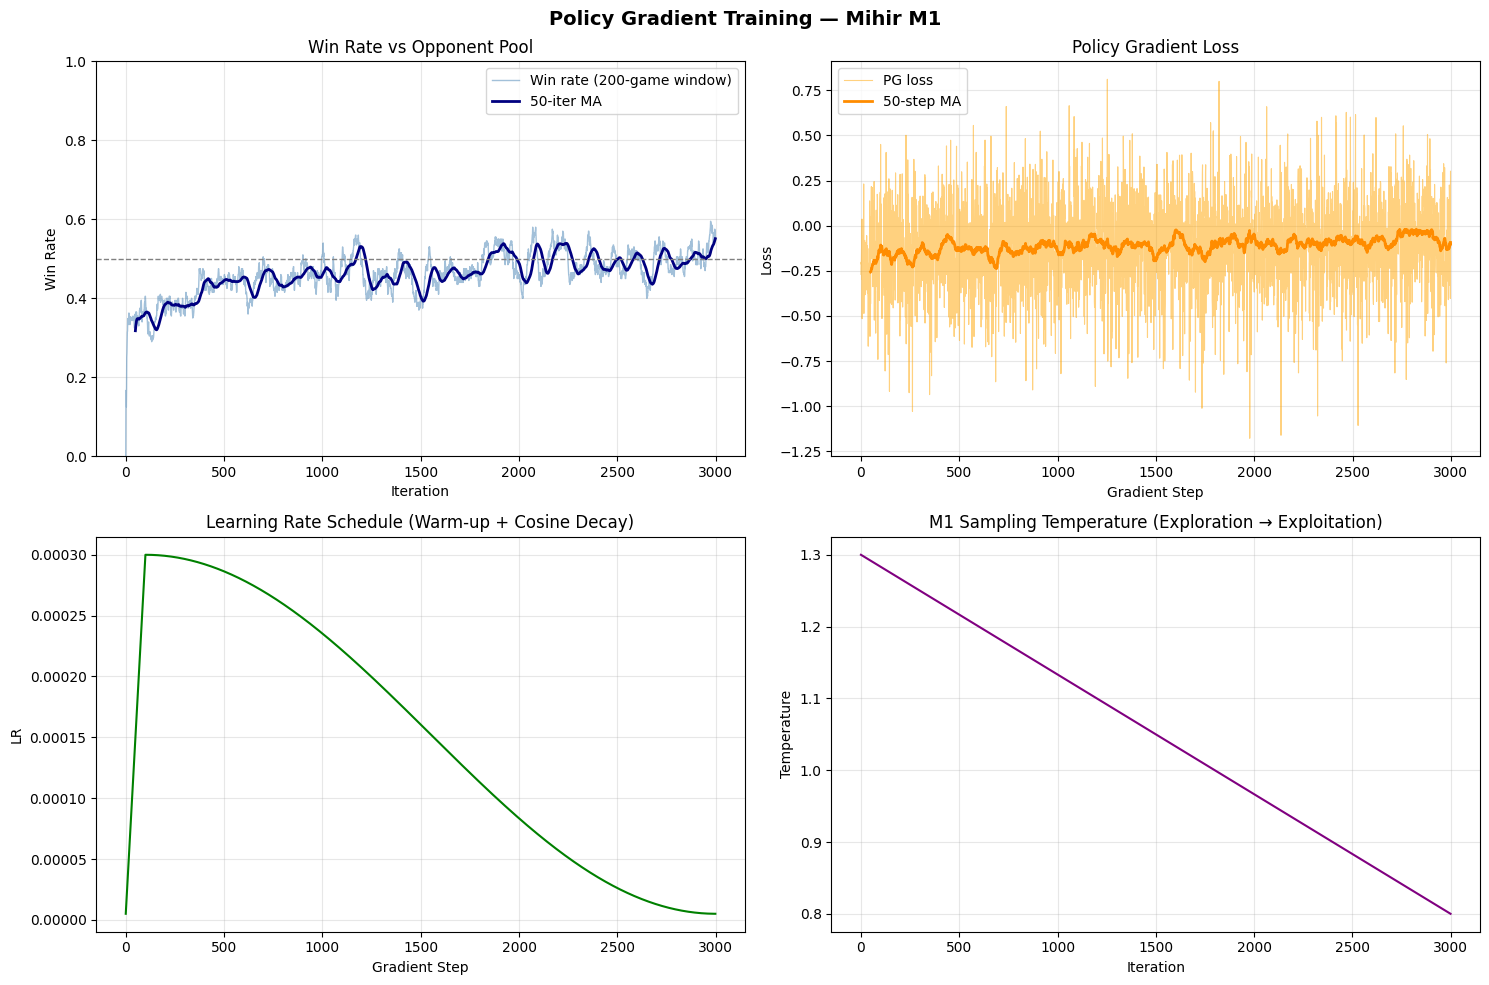

Total games: 18,000
  Wins:    8321 (46.2%)
  Losses:  8277 (46.0%)
  Draws:   1402 (7.8%)


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Policy Gradient Training — Mihir M1', fontsize=14, fontweight='bold')
window = 50

# ── Win rate ──────────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(win_rate_log, color='steelblue', lw=1, alpha=0.5, label='Win rate (200-game window)')
if len(win_rate_log) > window:
    sm = np.convolve(win_rate_log, np.ones(window)/window, mode='valid')
    ax.plot(range(window-1, len(win_rate_log)), sm, color='navy', lw=2, label=f'{window}-iter MA')
ax.axhline(0.5, color='gray', ls='--', lw=1)
ax.set_title('Win Rate vs Opponent Pool'); ax.set_xlabel('Iteration'); ax.set_ylabel('Win Rate')
ax.legend(); ax.set_ylim(0, 1); ax.grid(alpha=0.3)

# ── PG loss ───────────────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(loss_history, color='orange', lw=0.8, alpha=0.5, label='PG loss')
if len(loss_history) > window:
    sm = np.convolve(loss_history, np.ones(window)/window, mode='valid')
    ax.plot(range(window-1, len(loss_history)), sm, color='darkorange', lw=2, label=f'{window}-step MA')
ax.set_title('Policy Gradient Loss'); ax.set_xlabel('Gradient Step'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# ── Learning rate ─────────────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(lr_log, color='green', lw=1.5)
ax.set_title('Learning Rate Schedule (Warm-up + Cosine Decay)')
ax.set_xlabel('Gradient Step'); ax.set_ylabel('LR'); ax.grid(alpha=0.3)

# ── Temperature schedule ──────────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(temp_log, color='purple', lw=1.5)
ax.set_title('M1 Sampling Temperature (Exploration → Exploitation)')
ax.set_xlabel('Iteration'); ax.set_ylabel('Temperature'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pg_training_mihir.png', dpi=150, bbox_inches='tight')
plt.show()

total = len(all_outcomes)
wins  = sum(1 for o in all_outcomes if o == 'win')
draws = sum(1 for o in all_outcomes if o == 'draw')
print(f'Total games: {total:,}')
print(f'  Wins:   {wins:5d} ({wins/total:.1%})')
print(f'  Losses: {total-wins-draws:5d} ({(total-wins-draws)/total:.1%})')
print(f'  Draws:  {draws:5d} ({draws/total:.1%})')

## 10. Save Trained M1

In [11]:
m1.save('mihir_pg_trained.keras')
print('Saved → mihir_pg_trained.keras')

# Verify
m1_check = keras.models.load_model('mihir_pg_trained.keras', compile=False)
test_probs = get_probs_single(m1_check, create_board(), 1)
print(f'Test on empty board (player 1): {np.round(test_probs, 3)}')
print(f'Preferred column: {np.argmax(test_probs)} (expect 3 = centre)')

Saved → mihir_pg_trained.keras
Test on empty board (player 1): [0. 0. 0. 1. 0. 0. 0.]
Preferred column: 3 (expect 3 = centre)


## 11. Evaluation — Trained M1 vs All Opponents

Each matchup: 200 games, alternating first-mover. Greedy argmax policy (temperature=0.5) for both sides.

In [12]:
def evaluate(m1_trained, opp_model, opp_type, n_games=200, temperature=0.5):
    """Head-to-head evaluation. Returns {'win', 'loss', 'draw'} counts."""
    results = {'win': 0, 'loss': 0, 'draw': 0}
    for i in range(n_games):
        m1_player = (i % 2) + 1
        _, outcome = play_game(
            m1_trained, opp_model, opp_type, m1_player,
            n_random_init=0, m1_temp=temperature, m2_temp=temperature
        )
        results[outcome] += 1
    return results

eval_set = [
    ('vs Original M1',  m1_original, 'single'),
    ('vs Cass',         m2_cass,     'single'),
    ('vs Sophia',       m2_sophia,   'sophia'),
    ('vs Paolo',        m2_paolo,    'single'),
]

print('Evaluating trained M1 (200 games each) ...')
print()
eval_results = {}
for label, opp, otype in eval_set:
    r = evaluate(m1, opp, otype, n_games=200, temperature=0.5)
    total = sum(r.values())
    eval_results[label] = r
    print(f"{label:20s}  W={r['win']:3d} ({r['win']/total:.0%})  "
          f"D={r['draw']:3d} ({r['draw']/total:.0%})  "
          f"L={r['loss']:3d} ({r['loss']/total:.0%})")

Evaluating trained M1 (200 games each) ...

vs Original M1        W=146 (73%)  D= 10 (5%)  L= 44 (22%)
vs Cass               W=159 (80%)  D=  2 (1%)  L= 39 (20%)
vs Sophia             W=112 (56%)  D=  7 (4%)  L= 81 (40%)
vs Paolo              W=165 (82%)  D=  9 (4%)  L= 26 (13%)


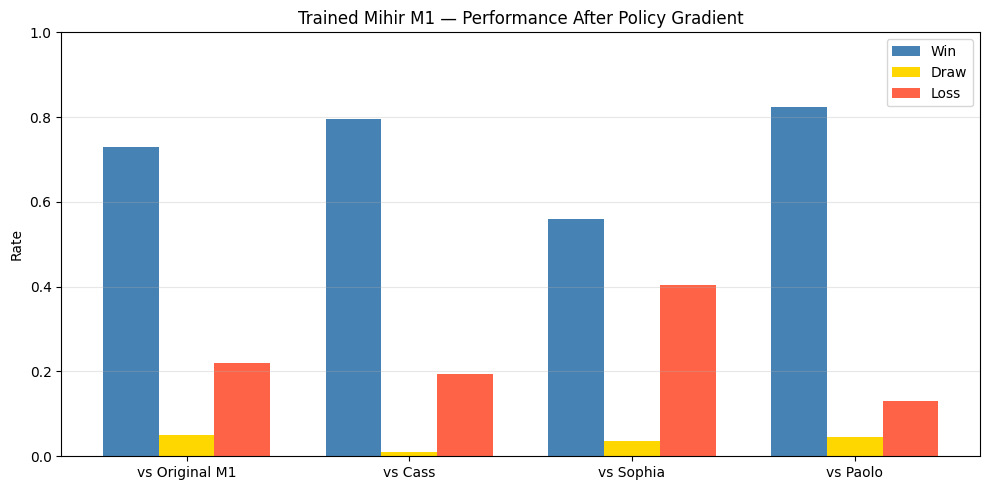

In [13]:
# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
labels = list(eval_results.keys())
x      = np.arange(len(labels))
w      = 0.25

def rate(r, k): return r[k] / sum(r.values())

ax.bar(x - w, [rate(eval_results[l], 'win')  for l in labels], w, label='Win',  color='steelblue')
ax.bar(x,     [rate(eval_results[l], 'draw') for l in labels], w, label='Draw', color='gold')
ax.bar(x + w, [rate(eval_results[l], 'loss') for l in labels], w, label='Loss', color='tomato')

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Rate'); ax.set_ylim(0, 1)
ax.set_title('Trained Mihir M1 — Performance After Policy Gradient')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('pg_eval_mihir.png', dpi=150, bbox_inches='tight')
plt.show()